# CREDIT DEFAULT PREDICTION USING LOGISTIC REGRESSION 

# Project Information

Project Type: Classification

Algorithm Used: Logistic Regression (Implemented from Scratch)

Dataset: Loan Default Prediction Dataset

Objective:
To develop a credit risk prediction system capable of identifying borrowers with a high probability of loan default. The project utilizes a custom-built Logistic Regression model to estimate default probabilities, evaluate borrower risk profiles, analyze feature importance, and assist financial institutions in making informed lending decisions while minimizing credit losses.

Tools Used:

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- Logistic Regression
- Gradient Descent
- Feature Scaling
- Statistical Analysis

### STEP 1: Import Required Libraries

The first step is to import the libraries required for data manipulation, numerical computations, visualization, preprocessing, model building, and
performance evaluation.

These libraries provide the foundation for developing the credit default prediction model.

In [112]:
import pandas as pd
import numpy as np

### STEP 2: Load the Dataset

The loan default dataset is loaded into a Pandas DataFrame for analysis.

This dataset contains borrower information, financial attributes, and the target variable indicating whether a borrower defaulted on a loan.

In [113]:
df = pd.read_csv("Loan_default.csv.zip")

### STEP 3: Examine Dataset Dimensions

The shape of the dataset is inspected to determine the number of observations and variables available for analysis.
The column names and data types are examined to understand the structure of the dataset.

This helps identify numerical and categorical variables that may require preprocessing before model training.

In [114]:
print("Shape of Dataset:", df.shape)

Shape of Dataset: (255347, 18)


In [115]:
print(df.columns)

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')


In [116]:
print(df.dtypes)

LoanID             object
Age                 int64
Income              int64
LoanAmount          int64
CreditScore         int64
MonthsEmployed      int64
NumCreditLines      int64
InterestRate      float64
LoanTerm            int64
DTIRatio          float64
Education          object
EmploymentType     object
MaritalStatus      object
HasMortgage        object
HasDependents      object
LoanPurpose        object
HasCoSigner        object
Default             int64
dtype: object


### STEP 5: Check Missing Values

Missing values can negatively affect model performance.

A custom function is created to identify columns containing null or missing observations.

In [117]:
def check_missing_values(data):
    
    missing = data.isnull().sum()
    
    return missing[missing > 0]

In [118]:
def dataset_summary(data):
    
    return data.describe()

In [119]:
def drop_column(data, column_name):
    
    data = data.drop(column_name, axis=1)
    
    return data

In [120]:
check_missing_values(df)

Series([], dtype: int64)

### STEP 6: Generate Statistical Summary

Descriptive statistics are generated to understand the distribution of numerical variables.

Measures such as mean, standard deviation, minimum, maximum, and quartiles are examined.

In [121]:
dataset_summary(df)

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Default
count,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000,255347.000000
mean,43.498306,82499.304597,127578.865512,574.264346,59.541976,2.501036,13.492773,36.025894,0.500212,0.116128
std,14.990258,38963.013729,70840.706142,158.903867,34.643376,1.117018,6.636443,16.969330,0.230917,0.320379
min,18.000000,15000.000000,5000.000000,300.000000,0.000000,1.000000,2.000000,12.000000,0.100000,0.000000
25%,31.000000,48825.500000,66156.000000,437.000000,30.000000,2.000000,7.770000,24.000000,0.300000,0.000000
50%,43.000000,82466.000000,127556.000000,574.000000,60.000000,2.000000,13.460000,36.000000,0.500000,0.000000
75%,56.000000,116219.000000,188985.000000,712.000000,90.000000,3.000000,19.250000,48.000000,0.700000,0.000000
max,69.000000,149999.000000,249999.000000,849.000000,119.000000,4.000000,25.000000,60.000000,0.900000,1.000000


### STEP 7: Data Cleaning

A custom function is created to remove unnecessary columns.

The LoanID column is dropped because it acts only as an identifier and does not contribute to loan default prediction.

In [122]:
df = drop_column(df, 'LoanID')

In [123]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,Bachelor's,Full-time,Divorced,Yes,Yes,Other,Yes,0
1,69,50432,124440,458,15,1,4.81,60,0.68,Master's,Full-time,Married,No,No,Other,Yes,0
2,46,84208,129188,451,26,3,21.17,24,0.31,Master's,Unemployed,Divorced,Yes,Yes,Auto,No,1
3,32,31713,44799,743,0,3,7.07,24,0.23,High School,Full-time,Married,No,No,Business,No,0
4,60,20437,9139,633,8,4,6.51,48,0.73,Bachelor's,Unemployed,Divorced,No,Yes,Auto,No,0


### STEP 8: Import Visualization Libraries

Visualization tools are imported to explore relationships, distributions, and patterns within the dataset.

In [124]:
import matplotlib.pyplot as plt
import seaborn as sns

### STEP 9: Analyze Loan Default Distribution

The target variable distribution is examined to understand the proportion of borrowers who defaulted versus those who did not.

This helps identify class imbalance issues.

Default
0    225694
1     29653
Name: count, dtype: int64


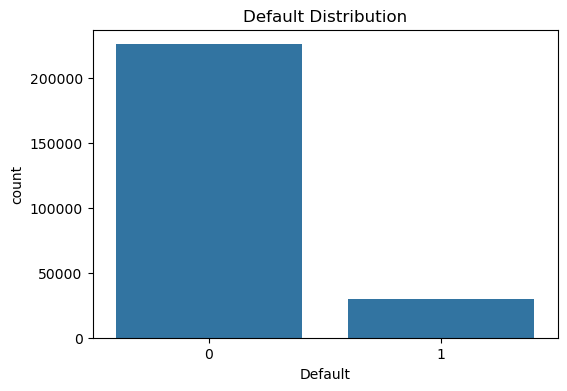

In [125]:
print(df['Default'].value_counts())

plt.figure(figsize=(6,4))

sns.countplot(x=df['Default'])

plt.title("Default Distribution")

plt.show()

### Interpretation

The chart displays the number of default and non-default cases.

If one class significantly outnumbers the other, the dataset is considered imbalanced, which may influence model performance and evaluation metrics.

### STEP 10: Encode Categorical Variables

Machine learning algorithms require numerical input.

A custom label encoding technique is applied to transform categorical variables into numerical representations.

In [126]:
def custom_label_encoder(data, column):
    
    unique_values = data[column].unique()
    
    mapping = {}
    
    for i, value in enumerate(unique_values):
        
        mapping[value] = i
        
    data[column] = data[column].map(mapping)
    
    return data, mapping

In [127]:
categorical_columns = [
    'Education',
    'EmploymentType',
    'MaritalStatus',
    'HasMortgage',
    'HasDependents',
    'LoanPurpose',
    'HasCoSigner'
]

encoding_mappings = {}

for col in categorical_columns:
    
    df, mapping = custom_label_encoder(df, col)
    
    encoding_mappings[col] = mapping

In [128]:
df.head()

,Age,Income,LoanAmount,CreditScore,MonthsEmployed,NumCreditLines,InterestRate,LoanTerm,DTIRatio,Education,EmploymentType,MaritalStatus,HasMortgage,HasDependents,LoanPurpose,HasCoSigner,Default
0,56,85994,50587,520,80,4,15.23,36,0.44,0,0,0,0,0,0,0,0
1,69,50432,124440,458,15,1,4.81,60,0.68,1,0,1,1,1,0,0,0
2,46,84208,129188,451,26,3,21.17,24,0.31,1,1,0,0,0,1,1,1
3,32,31713,44799,743,0,3,7.07,24,0.23,2,0,1,1,1,2,1,0
4,60,20437,9139,633,8,4,6.51,48,0.73,0,1,0,1,0,1,1,0


### Interpretation

Categorical features were successfully converted into numerical form, making them suitable for model training.

### STEP 11: Correlation Analysis

A correlation heatmap is generated to examine relationships among variables.

Strong positive or negative correlations may indicate important predictors of loan default.

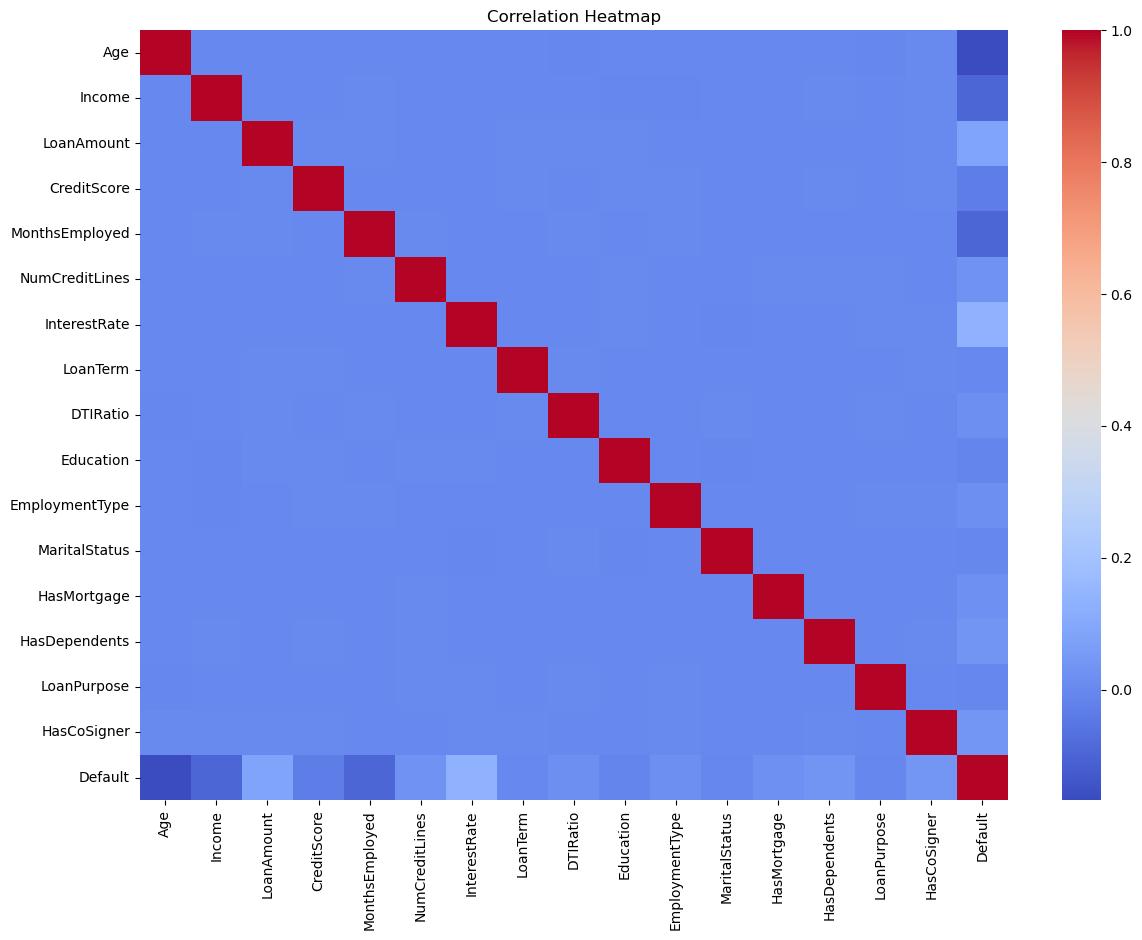

In [129]:
plt.figure(figsize=(14,10))

sns.heatmap(df.corr(), cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

### Interpretation

The heatmap highlights relationships between variables. Features showing stronger relationships with the target variable may contribute more 
significantly to default prediction.

### STEP 12: Define Features and Target Variable

The dataset is divided into:

- Features (X)
- Target Variable (y)

The target variable indicates whether a borrower defaulted on the loan.

In [130]:
X = df.drop('Default', axis=1).values

y = df['Default'].values

### STEP 13: Train-Test Split

The dataset is divided into training and testing sets.

The training set is used to build the model, while the testing set is reserved for evaluating performance on unseen data.

In [131]:
print(df.columns)

Index(['Age', 'Income', 'LoanAmount', 'CreditScore', 'MonthsEmployed',
       'NumCreditLines', 'InterestRate', 'LoanTerm', 'DTIRatio', 'Education',
       'EmploymentType', 'MaritalStatus', 'HasMortgage', 'HasDependents',
       'LoanPurpose', 'HasCoSigner', 'Default'],
      dtype='object')


In [132]:
def custom_train_test_split(X, y, test_size=0.2, random_state=42):
    
    np.random.seed(random_state)
    
    indices = np.arange(len(X))
    
    np.random.shuffle(indices)
    
    split_index = int(len(X) * (1 - test_size))
    
    train_indices = indices[:split_index]
    
    test_indices = indices[split_index:]
    
    X_train = X[train_indices]
    X_test = X[test_indices]
    
    y_train = y[train_indices]
    y_test = y[test_indices]
    
    return X_train, X_test, y_train, y_test

In [133]:
X_train, X_test, y_train, y_test = custom_train_test_split(
    X,
    y,
    test_size=0.2
)

print("Training Shape:", X_train.shape)

print("Testing Shape:", X_test.shape)

Training Shape: (204277, 16)
Testing Shape: (51070, 16)


### Interpretation

The dataset was successfully partitioned into training and testing subsets, enabling unbiased model evaluation.

### STEP 14: Feature Scaling

A custom standardization method is implemented to scale numerical variables.

Feature scaling ensures that all variables contribute equally during model training.

In [134]:
class CustomStandardScaler:
    
    def fit(self, X):
        
        self.mean = np.mean(X, axis=0)
        
        self.std = np.std(X, axis=0)
        
        
    def transform(self, X):
        
        return (X - self.mean) / self.std
    
    
    def fit_transform(self, X):
        
        self.fit(X)
        
        return self.transform(X)

In [135]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

### STEP 15: Sigmoid Function

The sigmoid function converts linear outputs into probability values ranging between 0 and 1.

This function forms the mathematical foundation of logistic regression.

The sigmoid function allows logistic regression to estimate the probability that a borrower will default on a loan.

In [136]:
def sigmoid(z):

    z = np.clip(z, -500, 500)

    return 1 / (1 + np.exp(-z))

### STEP 16: Build Logistic Regression Model

A custom logistic regression algorithm is implemented from scratch.

The model learns relationships between borrower characteristics and default outcomes using gradient descent optimization.

In [168]:
class CustomLogisticRegression:

    def __init__(self, learning_rate=0.01, iterations=5000):
        self.learning_rate = learning_rate
        self.iterations = iterations

    def fit(self, X, y):

        rows, cols = X.shape

        self.weights = np.zeros(cols)
        self.bias = 0

        for _ in range(self.iterations):

            linear_model = np.dot(X, self.weights) + self.bias

            predictions = sigmoid(linear_model)

            dw = (1 / rows) * np.dot(X.T, (predictions - y))
            db = (1 / rows) * np.sum(predictions - y)

            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db

    def predict_probability(self, X):

        linear_model = np.dot(X, self.weights) + self.bias

        return sigmoid(linear_model)

    def predict(self, X, threshold=0.5):

        probabilities = self.predict_probability(X)

        return (probabilities >= threshold).astype(int)

### STEP 17: Generate Predictions

The trained model is applied to the testing dataset to predict loan default outcomes and corresponding probabilities.

In [169]:
model = CustomLogisticRegression(
    learning_rate=0.01,
    iterations=5000
)

model.fit(X_train, y_train)

In [175]:
y_pred = model.predict(
    X_test_scaled,
    threshold=0.2
)

In [176]:
y_prob = model.predict_probability(X_test)

In [177]:
print(y_pred[:10])
print(y_prob[:10])

[0 0 0 0 0 0 0 0 0 1]
[0.18822566 0.10702045 0.11548234 0.09115793 0.05910977 0.18306666
 0.0801285  0.18593774 0.11327439 0.2026247 ]


In [178]:
y_prob = model.predict_probability(X_test)

print(np.min(y_prob))
print(np.max(y_prob))
print(np.mean(y_prob))

0.0035520768079837315
0.7089125211578622
0.12028110596228052


### STEP 18: Model Accuracy Evaluation

Accuracy measures the proportion of correctly classified observations among all predictions.

In [179]:
accuracy = np.mean(y_pred == y_test)

print("Accuracy:", accuracy)

Accuracy: 0.8140199725866458


### Interpretation

The accuracy score indicates the overall percentage of correct predictions made by the model.

### STEP 19: Confusion Matrix Analysis

A confusion matrix is generated to summarize classification results.

It provides information about:

- True Positives
- True Negatives
- False Positives
- False Negatives

In [180]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[39099  6133]
 [ 3365  2473]]


In [181]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.86      0.89     45232
           1       0.29      0.42      0.34      5838

    accuracy                           0.81     51070
   macro avg       0.60      0.64      0.62     51070
weighted avg       0.85      0.81      0.83     51070



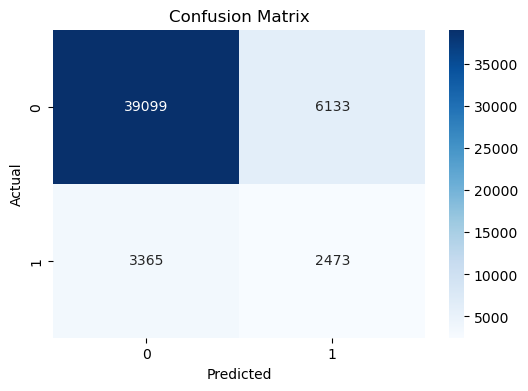

In [182]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

### Interpretation

The confusion matrix provides a detailed breakdown of model performance and helps identify classification errors.

### STEP 20: Precision, Recall and F1 Score

Additional evaluation metrics are calculated to assess model performance more comprehensively.

These metrics are particularly important when class distributions are imbalanced.

In [183]:
def precision(y_true, y_pred):

    tp = np.sum((y_true == 1) & (y_pred == 1))

    fp = np.sum((y_true == 0) & (y_pred == 1))

    if (tp + fp) == 0:
        return 0.0

    return tp / (tp + fp)

In [184]:
def recall(y_true, y_pred):

    tp = np.sum((y_true == 1) & (y_pred == 1))

    fn = np.sum((y_true == 1) & (y_pred == 0))

    if (tp + fn) == 0:
        return 0.0

    return tp / (tp + fn)

In [185]:
def f1_score(y_true, y_pred):

    p = precision(y_true, y_pred)

    r = recall(y_true, y_pred)

    if (p + r) == 0:
        return 0.0

    return 2 * (p * r) / (p + r)

In [186]:
print("Precision:", precision(y_test, y_pred))
print("Recall:", recall(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Precision: 0.2873576574482919
Recall: 0.4236039739636862
F1 Score: 0.342425920797563


### Interpretation

Precision = 28.74% . 
Precision evaluates the reliability of positive predictions.
Of all customers predicted as defaulters, approximately 29% actually defaulted.


Recall = 42.36%. 
Recall measures the ability to identify actual defaults
The model correctly identifies approximately 42% of all actual defaulters.


F1 Score = 34.24% .
The F1 Score is a single metric that combines Precision and Recall into one number.
The model has a moderate balance between identifying defaulters (Recall) and making correct default predictions (Precision).


### STEP 21: Threshold Optimization

The default classification threshold is adjusted from 0.20 to 0.30.

This is to check the model.

In [187]:
def accuracy(y_true, y_pred):

    return np.mean(y_true == y_pred)

In [188]:
custom_predictions = model.predict(
    X_test_scaled,
    threshold=0.3
)

print("Accuracy with Threshold 0.3:")

print(accuracy(y_test, custom_predictions))

Accuracy with Threshold 0.3:
0.8737615038182887


### Interpretation

Lowering the threshold increases sensitivity to default cases but may also increase false positive predictions.

### STEP 22: Feature Importance Analysis

The model coefficients are analyzed to determine which borrower characteristics most strongly influence loan default probability.

Odds ratios are also calculated to improve interpretability.

In [164]:
feature_names = df.drop('Default', axis=1).columns

coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': model.weights
})

coefficients

,Feature,Coefficient
0,Age,-0.537617
1,Income,-0.318021
2,LoanAmount,0.282209
3,CreditScore,-0.115330
4,MonthsEmployed,-0.309938
5,NumCreditLines,0.091124
6,InterestRate,0.422248
7,LoanTerm,-0.000806
8,DTIRatio,0.060111
9,Education,-0.029324


In [165]:
coefficients['Odds_Ratio'] = np.exp(coefficients['Coefficient'])

coefficients

,Feature,Coefficient,Odds_Ratio
0,Age,-0.537617,0.584139
1,Income,-0.318021,0.727588
2,LoanAmount,0.282209,1.326056
3,CreditScore,-0.115330,0.891072
4,MonthsEmployed,-0.309938,0.733492
5,NumCreditLines,0.091124,1.095405
6,InterestRate,0.422248,1.525387
7,LoanTerm,-0.000806,0.999194
8,DTIRatio,0.060111,1.061954
9,Education,-0.029324,0.971102


In [166]:
coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

coefficients

,Feature,Coefficient,Odds_Ratio
6,InterestRate,0.422248,1.525387
2,LoanAmount,0.282209,1.326056
15,HasCoSigner,0.126150,1.134452
13,HasDependents,0.108758,1.114892
5,NumCreditLines,0.091124,1.095405
12,HasMortgage,0.068463,1.070861
10,EmploymentType,0.063842,1.065924
8,DTIRatio,0.060111,1.061954
7,LoanTerm,-0.000806,0.999194
11,MaritalStatus,-0.023715,0.976564


### Interpretation

Positive coefficients increase the probability of default, while negative coefficients reduce default risk.

The feature importance chart helps identify the most influential variables affecting lending decisions.

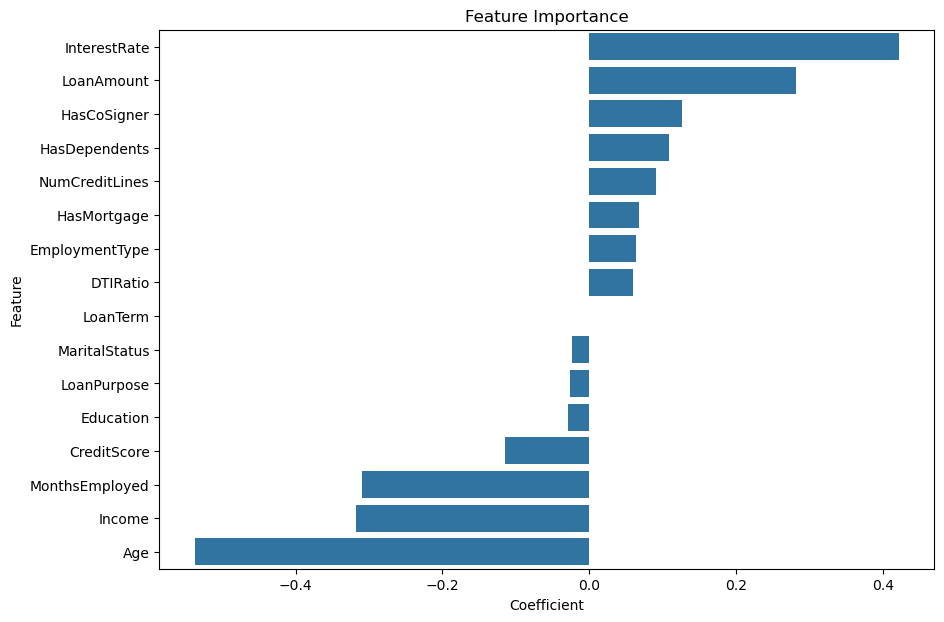

In [167]:
plt.figure(figsize=(10,7))

sns.barplot(
    x='Coefficient',
    y='Feature',
    data=coefficients
)

plt.title("Feature Importance")

plt.show()

### Interpretation

The coefficient graph illustrates the influence of each predictor variable on the probability of loan default.

In Logistic Regression, each coefficient represents the change in the log-odds of default associated with a one-unit increase in the corresponding feature while holding all other variables constant.

Key observations:

- Features with positive coefficients increase the probability of loan default.
- Features with negative coefficients decrease the probability of loan default.
- Variables with larger absolute coefficient values have a stronger impact on the model's predictions.
- Features with coefficients close to zero contribute relatively little to default prediction.

The graph helps identify the most influential borrower characteristics affecting credit risk. Variables with the highest positive coefficients can be considered major risk indicators, while variables with strong negative coefficients may represent factors associated with financially stable borrowers.

From a business perspective, these insights can assist financial institutions in understanding the key drivers of loan default, improving risk assessment strategies, and making more informed lending decisions.


# Conclusion

A Credit Default Prediction System was successfully developed using Logistic Regression.

The project involved data preprocessing, categorical encoding, feature scaling, model training, performance evaluation, threshold optimization, and feature importance analysis.

The logistic regression model successfully estimated default probabilities and classified borrowers into default and non-default categories. Evaluation metrics demonstrated the effectiveness of the model in identifying risky borrowers.

The project highlights how machine learning can assist financial institutions in improving credit risk assessment, reducing loan losses, and supporting data-driven lending decisions.